# Women's Empowerment Index - Multivariate Regression Analysis

## Mission
To predict a country's Women's Empowerment Index (WEI) score using gender parity 
and human development indicators, identifying which factors most influence 
women's empowerment globally.

## Dataset
- Source: Kaggle - Women Empowerment Index
- 114 countries, 7 features including GGPI, Gender Parity Group, Human Development Group

In [13]:
# Cell 1: Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## Key Findings from Visualizations
- GGPI has the strongest correlation with WEI at -0.84
- Gender Parity Group has the weakest correlation at -0.07 and was least useful
- Most countries score between 0.5 and 0.8 on the WEI scale

In [2]:
# Cell 2: Load the dataset and take a first look
df = pd.read_csv('women_empowerment_index.csv')

print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (114, 7)

First 5 rows:


,Country,Women's Empowerment Index (WEI) - 2022,Women's Empowerment Group - 2022,Global Gender Parity Index (GGPI) - 2022,Gender Parity Group - 2022,Human Development Group - 2021,Sustainable Development Goal regions
0,Australia,0.805,High,0.870,High,Very high,Australia and New Zealand
1,Belgium,0.801,High,0.869,High,Very high,Europe and Northern America
2,Denmark,0.804,High,0.845,High,Very high,Europe and Northern America
3,Iceland,0.816,High,0.914,High,Very high,Europe and Northern America
4,Norway,0.802,High,0.887,High,Very high,Europe and Northern America


## Model Results
- Random Forest performed best with R2 = 0.9514 and Test MSE = 0.0008
- Decision Tree overfit the training data (Train MSE = 0.0000)
- Linear Regression performed well with R2 = 0.8769

In [3]:
# Cell 3: Explore the data
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nBasic statistics:")
df.describe()

Column names:
['Country', "Women's Empowerment Index (WEI) - 2022", "Women's Empowerment Group - 2022", 'Global Gender Parity Index (GGPI) - 2022', 'Gender Parity Group - 2022', 'Human Development Group - 2021', 'Sustainable Development Goal regions']

Data types:
Country                                         str
Women's Empowerment Index (WEI) - 2022      float64
Women's Empowerment Group - 2022                str
Global Gender Parity Index (GGPI) - 2022    float64
Gender Parity Group - 2022                      str
Human Development Group - 2021                  str
Sustainable Development Goal regions            str
dtype: object

Missing values:
Country                                     0
Women's Empowerment Index (WEI) - 2022      0
Women's Empowerment Group - 2022            0
Global Gender Parity Index (GGPI) - 2022    0
Gender Parity Group - 2022                  0
Human Development Group - 2021              0
Sustainable Development Goal regions        0
dtype: int64

Basi

,Women's Empowerment Index (WEI) - 2022,Global Gender Parity Index (GGPI) - 2022
count,114.000000,114.000000
mean,0.607316,0.705237
std,0.134632,0.128897
min,0.141000,0.141000
25%,0.518000,0.622250
50%,0.615000,0.726500
75%,0.705500,0.802000
max,0.828000,0.925000


In [14]:
# Cell 4: Feature Engineering

# Drop 'Country' - it's just a name, not useful for prediction
df_clean = df.drop(columns=['Country'])

# Convert text columns to numbers using Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

text_columns = [
    "Women's Empowerment Group - 2022",
    "Gender Parity Group - 2022",
    "Human Development Group - 2021",
    "Sustainable Development Goal regions"
]

for col in text_columns:
    df_clean[col] = le.fit_transform(df_clean[col])

print("Text columns converted to numbers!")
print("\nClean dataset preview:")
df_clean.head()

Text columns converted to numbers!

Clean dataset preview:


,Women's Empowerment Index (WEI) - 2022,Women's Empowerment Group - 2022,Global Gender Parity Index (GGPI) - 2022,Gender Parity Group - 2022,Human Development Group - 2021,Sustainable Development Goal regions
0,0.805,0,0.870,0,3,0
1,0.801,0,0.869,0,3,3
2,0.804,0,0.845,0,3,3
3,0.816,0,0.914,0,3,3
4,0.802,0,0.887,0,3,3


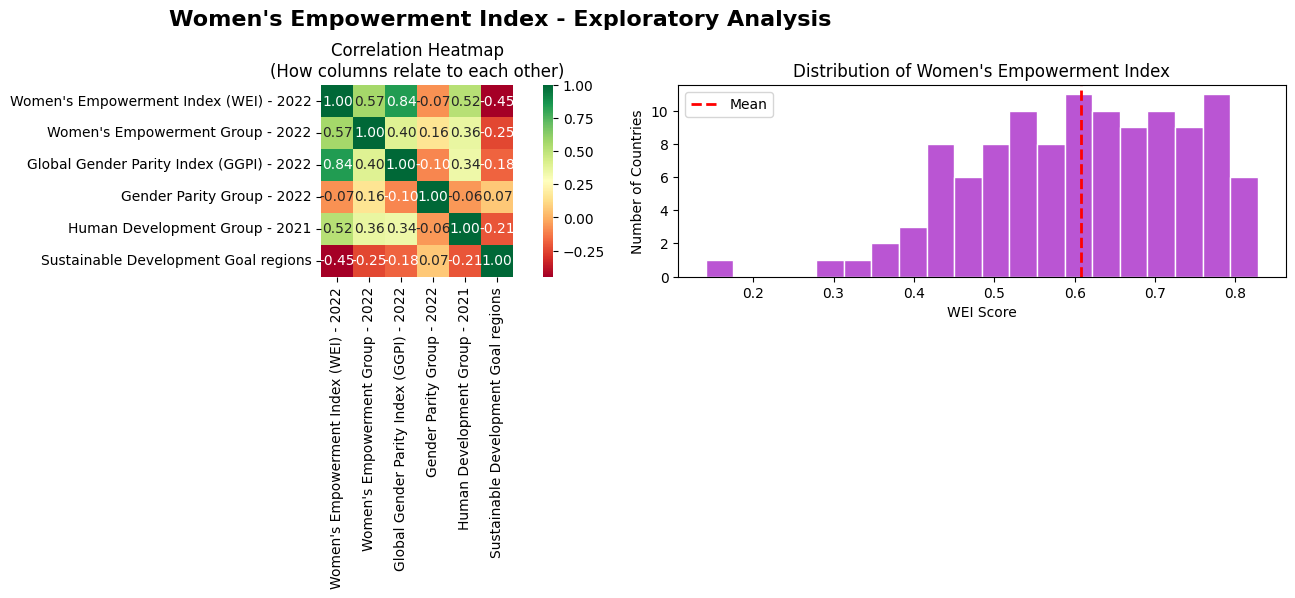

Visualizations saved!


In [6]:
# Cell 5: Visualizations

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Women's Empowerment Index - Exploratory Analysis", fontsize=16, fontweight='bold')

# --- Plot 1: Correlation Heatmap ---
ax1 = axes[0]
correlation = df_clean.corr()
sns.heatmap(correlation, 
            annot=True, 
            fmt='.2f', 
            cmap='RdYlGn',
            ax=ax1,
            square=True)
ax1.set_title("Correlation Heatmap\n(How columns relate to each other)", fontsize=12)

# --- Plot 2: Distribution of WEI (our target variable) ---
ax2 = axes[1]
ax2.hist(df_clean["Women's Empowerment Index (WEI) - 2022"], 
         bins=20, 
         color='mediumorchid', 
         edgecolor='white')
ax2.set_title("Distribution of Women's Empowerment Index", fontsize=12)
ax2.set_xlabel("WEI Score")
ax2.set_ylabel("Number of Countries")
ax2.axvline(df_clean["Women's Empowerment Index (WEI) - 2022"].mean(), 
            color='red', linestyle='--', linewidth=2, label='Mean')
ax2.legend()

plt.tight_layout()
plt.savefig('visualizations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualizations saved!")

In [7]:
# Cell 6: Define features, standardize, and split data

# X = inputs (features), y = target (what we predict)
X = df_clean.drop(columns=["Women's Empowerment Index (WEI) - 2022"])
y = df_clean["Women's Empowerment Index (WEI) - 2022"]

# Split into training set (80%) and test set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize - scale all numbers to the same range
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("Standardization complete.")

Training set size: (91, 5)
Test set size: (23, 5)
Standardization complete.


In [8]:
# Cell 7: Train Linear Regression, Decision Tree, and Random Forest

# --- Model 1: Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_train_pred = lr_model.predict(X_train_scaled)
lr_test_pred = lr_model.predict(X_test_scaled)
lr_train_mse = mean_squared_error(y_train, lr_train_pred)
lr_test_mse = mean_squared_error(y_test, lr_test_pred)
lr_r2 = r2_score(y_test, lr_test_pred)

# --- Model 2: Decision Tree ---
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_scaled, y_train)
dt_train_pred = dt_model.predict(X_train_scaled)
dt_test_pred = dt_model.predict(X_test_scaled)
dt_train_mse = mean_squared_error(y_train, dt_train_pred)
dt_test_mse = mean_squared_error(y_test, dt_test_pred)
dt_r2 = r2_score(y_test, dt_test_pred)

# --- Model 3: Random Forest ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_train_pred = rf_model.predict(X_train_scaled)
rf_test_pred = rf_model.predict(X_test_scaled)
rf_train_mse = mean_squared_error(y_train, rf_train_pred)
rf_test_mse = mean_squared_error(y_test, rf_test_pred)
rf_r2 = r2_score(y_test, rf_test_pred)

# --- Compare all models ---
print("Model Comparison (lower MSE = better, higher R2 = better)")
print("-" * 55)
print(f"{'Model':<20} {'Train MSE':<15} {'Test MSE':<15} {'R2 Score'}")
print("-" * 55)
print(f"{'Linear Regression':<20} {lr_train_mse:<15.4f} {lr_test_mse:<15.4f} {lr_r2:.4f}")
print(f"{'Decision Tree':<20} {dt_train_mse:<15.4f} {dt_test_mse:<15.4f} {dt_r2:.4f}")
print(f"{'Random Forest':<20} {rf_train_mse:<15.4f} {rf_test_mse:<15.4f} {rf_r2:.4f}")

Model Comparison (lower MSE = better, higher R2 = better)
-------------------------------------------------------
Model                Train MSE       Test MSE        R2 Score
-------------------------------------------------------
Linear Regression    0.0026          0.0021          0.8769
Decision Tree        0.0000          0.0026          0.8472
Random Forest        0.0004          0.0008          0.9514


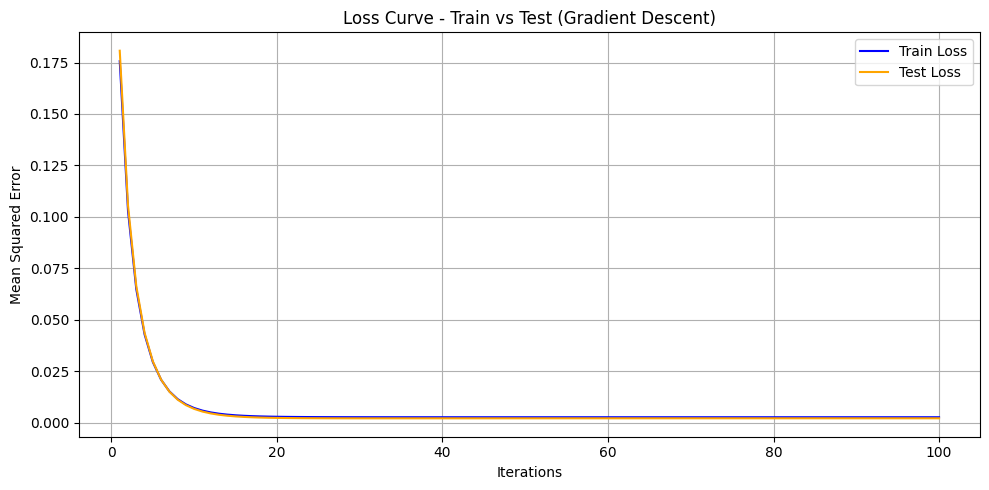

Loss curve saved.


In [9]:
# Cell 8: Loss curves using gradient descent iterations (Linear Regression)

from sklearn.linear_model import SGDRegressor

train_losses = []
test_losses = []

# Train step by step for 100 iterations to track loss
for i in range(1, 101):
    sgd_model = SGDRegressor(max_iter=i, random_state=42, tol=None)
    sgd_model.fit(X_train_scaled, y_train)
    
    train_pred = sgd_model.predict(X_train_scaled)
    test_pred = sgd_model.predict(X_test_scaled)
    
    train_losses.append(mean_squared_error(y_train, train_pred))
    test_losses.append(mean_squared_error(y_test, test_pred))

# Plot the loss curves
plt.figure(figsize=(10, 5))
plt.plot(range(1, 101), train_losses, label='Train Loss', color='blue')
plt.plot(range(1, 101), test_losses, label='Test Loss', color='orange')
plt.title('Loss Curve - Train vs Test (Gradient Descent)')
plt.xlabel('Iterations')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Loss curve saved.")

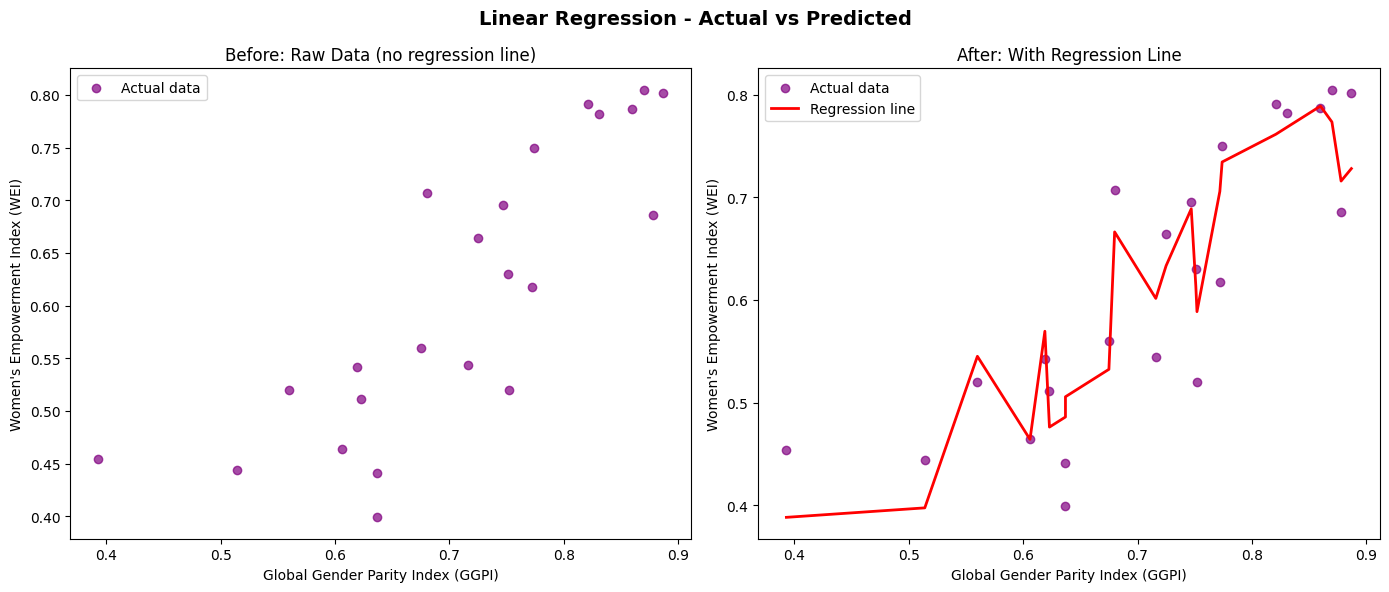

Scatter plot saved.


In [10]:
# Cell 9: Scatter plot showing actual vs predicted with regression line

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Linear Regression - Actual vs Predicted", fontsize=14, fontweight='bold')

# --- Before: Raw data scatter ---
axes[0].scatter(X_test['Global Gender Parity Index (GGPI) - 2022'], 
                y_test, 
                color='purple', alpha=0.7, label='Actual data')
axes[0].set_title("Before: Raw Data (no regression line)")
axes[0].set_xlabel("Global Gender Parity Index (GGPI)")
axes[0].set_ylabel("Women's Empowerment Index (WEI)")
axes[0].legend()

# --- After: With regression line ---
axes[1].scatter(X_test['Global Gender Parity Index (GGPI) - 2022'], 
                y_test, 
                color='purple', alpha=0.7, label='Actual data')

# Sort for a clean line
sorted_idx = X_test['Global Gender Parity Index (GGPI) - 2022'].argsort()
x_sorted = X_test['Global Gender Parity Index (GGPI) - 2022'].iloc[sorted_idx]
y_sorted = lr_test_pred[sorted_idx]

axes[1].plot(x_sorted, y_sorted, color='red', linewidth=2, label='Regression line')
axes[1].set_title("After: With Regression Line")
axes[1].set_xlabel("Global Gender Parity Index (GGPI)")
axes[1].set_ylabel("Women's Empowerment Index (WEI)")
axes[1].legend()

plt.tight_layout()
plt.savefig('scatter_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Scatter plot saved.")

In [11]:
# Cell 10: Save the best performing model (Random Forest)

joblib.dump(rf_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Best model: Random Forest")
print("R2 Score: 0.9514")
print("Test MSE: 0.0008")
print("Model saved as best_model.pkl")
print("Scaler saved as scaler.pkl")

Best model: Random Forest
R2 Score: 0.9514
Test MSE: 0.0008
Model saved as best_model.pkl
Scaler saved as scaler.pkl


In [12]:
# Cell 11: Use the best model to predict one data point

# Take the first row from the test set
sample = X_test.iloc[[0]]
actual_value = y_test.iloc[0]

# Scale it the same way we scaled training data
sample_scaled = scaler.transform(sample)

# Make prediction
prediction = rf_model.predict(sample_scaled)

print("Sample input data:")
print(sample.to_string())
print("\nActual WEI value:   ", round(actual_value, 4))
print("Predicted WEI value:", round(prediction[0], 4))
print("Difference:         ", round(abs(actual_value - prediction[0]), 4))

Sample input data:
    Women's Empowerment Group - 2022  Global Gender Parity Index (GGPI) - 2022  Gender Parity Group - 2022  Human Development Group - 2021  Sustainable Development Goal regions
80                                 1                                     0.716                           3                               2                                     4

Actual WEI value:    0.544
Predicted WEI value: 0.5597
Difference:          0.0157
